# Demo đồ án 2: H-Mine

Notebook này dùng để minh họa cho:

- **Chương 3: Cài đặt**
- **Chương 4: Thực nghiệm và đánh giá**

Nội dung notebook:
1. Kiểm tra môi trường
2. Gọi chương trình chính trên dữ liệu toy
3. Chạy bộ kiểm thử tính đúng đắn
4. Chạy benchmark
5. Đọc file CSV kết quả
6. Vẽ các biểu đồ cho báo cáo

In [1]:
import Pkg
Pkg.activate("..")
Pkg.add("Plots")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.instantiate()

  Activating project at `d:\Nam3\KhaiThacDuLieu\Lab2\Lab2_HMine`
   Resolving package versions...
     Project No packages added to or removed from `D:\Nam3\KhaiThacDuLieu\Lab2\Lab2_HMine\Project.toml`
    Manifest No packages added to or removed from `D:\Nam3\KhaiThacDuLieu\Lab2\Lab2_HMine\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `D:\Nam3\KhaiThacDuLieu\Lab2\Lab2_HMine\Project.toml`
    Manifest No packages added to or removed from `D:\Nam3\KhaiThacDuLieu\Lab2\Lab2_HMine\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `D:\Nam3\KhaiThacDuLieu\Lab2\Lab2_HMine\Project.toml`
    Manifest No packages added to or removed from `D:\Nam3\KhaiThacDuLieu\Lab2\Lab2_HMine\Manifest.toml`


In [2]:
using CSV
using DataFrames
using Statistics
using Dates

## 1. Kiểm tra thư mục làm việc
Cell này giúp kiểm tra notebook đang chạy đúng trong thư mục `notebooks/`.


In [3]:
pwd()

"d:\\Nam3\\KhaiThacDuLieu\\Lab2\\Lab2_HMine\\notebooks"

In [4]:
readdir("..")

13-element Vector{String}:
 ".git"
 "Manifest.toml"
 "Project.toml"
 "README.md"
 "data"
 "docs"
 "notebooks"
 "out_test.txt"
 "src"
 "temp.txt"
 "temp_ref.txt"
 "tests"
 "warmup.txt"

## 2. Nạp mã nguồn chính
Notebook chỉ gọi lại code đã cài đặt sẵn trong `src/`.

In [5]:
include("../src/main.jl")

## 3. Demo chạy thuật toán trên dữ liệu toy
Chạy thử bản cơ bản và bản tối ưu trên dữ liệu nhỏ ở Chương 2.


In [6]:
toy_input = "../data/toy/toy_example_ch2.txt"
toy_out_base = "../docs/toy_out_base.txt"
toy_out_opt  = "../docs/toy_out_opt.txt"

run_hmine(toy_input, 50, toy_out_base; optimized=false)
run_hmine(toy_input, 50, toy_out_opt; optimized=true)

println("Đã chạy xong trên toy dataset.")

In [7]:
println("=== Output bản cơ bản ===")
println(read(toy_out_base, String))

Đã chạy xong trên toy dataset.
=== Output bản cơ bản ===
1 #SUP: 4
1 3 #SUP: 3
1 3 4 #SUP: 3
1 4 #SUP: 4
1 4 5 #SUP: 3
1 5 #SUP: 3
3 #SUP: 5
3 4 #SUP: 5
3 4 5 #SUP: 4
3 5 #SUP: 4
4 #SUP: 6
4 5 #SUP: 5
4 5 7 #SUP: 3
4 7 #SUP: 3
5 #SUP: 5
5 7 #SUP: 3
7 #SUP: 3



In [8]:
println("=== Output bản tối ưu ===")
println(read(toy_out_opt, String))

=== Output bản tối ưu ===
1 #SUP: 4
1 3 #SUP: 3
1 3 4 #SUP: 3
1 4 #SUP: 4
1 4 5 #SUP: 3
1 5 #SUP: 3
3 #SUP: 5
3 4 #SUP: 5
3 4 5 #SUP: 4
3 5 #SUP: 4
4 #SUP: 6
4 5 #SUP: 5
4 5 7 #SUP: 3
4 7 #SUP: 3
5 #SUP: 5
5 7 #SUP: 3
7 #SUP: 3



## 4. Demo gọi chương trình bằng dòng lệnh
Cell này kiểm tra phần tham số dòng lệnh của `src/main.jl`.

In [9]:
run(`julia --project=.. ../src/main.jl ../data/toy/toy_example_ch2.txt 50 ../docs/toy_out_cli.txt true`)

Hoàn tất khai phá.
Input     : ../data/toy/toy_example_ch2.txt
Minsup(%) : 50.0
Output    : ../docs/toy_out_cli.txt
Optimized : true


Process(`julia --project=.. ../src/main.jl ../data/toy/toy_example_ch2.txt 50 ../docs/toy_out_cli.txt true`, ProcessExited(0))

In [10]:
println(read("../docs/toy_out_cli.txt", String))

1 #SUP: 4
1 3 #SUP: 3
1 3 4 #SUP: 3
1 4 #SUP: 4
1 4 5 #SUP: 3
1 5 #SUP: 3
3 #SUP: 5
3 4 #SUP: 5
3 4 5 #SUP: 4
3 5 #SUP: 4
4 #SUP: 6
4 5 #SUP: 5
4 5 7 #SUP: 3
4 7 #SUP: 3
5 #SUP: 5
5 7 #SUP: 3
7 #SUP: 3



## 5. Chạy bộ kiểm thử tính đúng đắn
Cell này gọi file `tests/runtests.jl`.
Lưu ý: cell này có thể mất một lúc vì phải đối chiếu với SPMF.

In [11]:
cd("..") do
    run(`julia --project=. tests/runtests.jl`)
end


>>> Đang xử lý tập dữ liệu: data/toy/toy_example_ch2.txt
1. Đang gọi SPMF để tạo đáp án chuẩn...
>/D:/Nam3/KhaiThacDuLieu/Lab2/Lab2_HMine/data/spmf.jar
=============  HMine ALGORITHM v96r18- STATS =============
 Total time ~ 4 ms
 Max Memory ~ 2.9802017211914062 MB
 Frequent itemsets count : 17
2a. Đang chạy H-Mine (bản gốc)...
2b. Đang chạy H-Mine (bản tối ưu)...
3. Đang đối soát kết quả...
=> KẾT QUẢ KHỚP 100% (17 itemsets)

>>> Đang xử lý tập dữ liệu: data/benchmark/mushrooms.txt
1. Đang gọi SPMF để tạo đáp án chuẩn...
>/D:/Nam3/KhaiThacDuLieu/Lab2/Lab2_HMine/data/spmf.jar
=============  HMine ALGORITHM v96r18- STATS =============
 Total time ~ 201 ms
 Max Memory ~ 22.12775421142578 MB
 Frequent itemsets count : 163
2a. Đang chạy H-Mine (bản gốc)...
2b. Đang chạy H-Mine (bản tối ưu)...
3. Đang đối soát kết quả...
=> KẾT QUẢ KHỚP 100% (163 itemsets)

>>> Đang xử lý tập dữ liệu: data/benchmark/accidents.txt
1. Đang gọi SPMF để tạo đáp án chuẩn...
>/D:/Nam3/KhaiThacDuLieu/Lab2/Lab2_HM

Process(`julia --project=. tests/runtests.jl`, ProcessExited(0))

## 6. Chạy benchmark
Cell này gọi file `tests/test_benchmark.jl` để sinh các file CSV kết quả.

Nếu đã chạy benchmark từ trước rồi thì có thể bỏ qua cell này và chạy trực tiếp các cell đọc CSV bên dưới.

## 7. Đọc dữ liệu kết quả benchmark
Các file CSV được dùng để trực quan hóa cho Chương 4.

In [12]:
benchmark_df = CSV.read("../docs/benchmark_results.csv", DataFrame)
scalability_df = CSV.read("../docs/scalability_results.csv", DataFrame)
avglen_df = CSV.read("../docs/avg_transaction_length_results.csv", DataFrame)

Row,Avg_Transaction_Length,Time_ms,Peak_RAM_MB,Pattern_Count
,Int64,Float64,Float64,Int64
1,5,6.6412,4.88134,49
2,10,8.2234,12.8469,100
3,15,10.7443,14.6042,100
4,20,15.4391,16.525,102
5,25,475.486,66.1568,5047


In [13]:
first(benchmark_df, 10)

Row,Dataset,Minsup,Version,Time_ms,Peak_RAM_MB,Correctness,Pattern_Count
,String15,Float64,String15,Float64,String31,Float64,Int64
1,mushrooms.txt,60.0,SPMF,378.814,missing,100.0,51
2,mushrooms.txt,60.0,Base,27.6016,32.179786682128906,100.0,51
3,mushrooms.txt,60.0,Optimized,17.8282,31.418338775634766,100.0,51
4,mushrooms.txt,55.0,SPMF,401.508,missing,100.0,115
5,mushrooms.txt,55.0,Base,21.8878,37.51973342895508,100.0,115
6,mushrooms.txt,55.0,Optimized,20.8853,34.44710159301758,100.0,115
7,mushrooms.txt,50.0,SPMF,421.551,missing,100.0,163
8,mushrooms.txt,50.0,Base,23.9739,41.41688919067383,100.0,163
9,mushrooms.txt,50.0,Optimized,25.648,30.633045196533203,100.0,163


In [14]:
benchmark_df

Row,Dataset,Minsup,Version,Time_ms,Peak_RAM_MB,Correctness,Pattern_Count
,String15,Float64,String15,Float64,String31,Float64,Int64
1,mushrooms.txt,60.0,SPMF,378.814,missing,100.0,51
2,mushrooms.txt,60.0,Base,27.6016,32.179786682128906,100.0,51
3,mushrooms.txt,60.0,Optimized,17.8282,31.418338775634766,100.0,51
4,mushrooms.txt,55.0,SPMF,401.508,missing,100.0,115
5,mushrooms.txt,55.0,Base,21.8878,37.51973342895508,100.0,115
6,mushrooms.txt,55.0,Optimized,20.8853,34.44710159301758,100.0,115
7,mushrooms.txt,50.0,SPMF,421.551,missing,100.0,163
8,mushrooms.txt,50.0,Base,23.9739,41.41688919067383,100.0,163
9,mushrooms.txt,50.0,Optimized,25.648,30.633045196533203,100.0,163


In [15]:
using Plots

In [16]:

clean_name(ds) = replace(ds, ".txt" => "")
mkpath("../docs/figures")

default(
    size = (1200, 800),
    left_margin = 6Plots.mm,
    right_margin = 4Plots.mm,
    top_margin = 6Plots.mm,
    bottom_margin = 6Plots.mm,
    legendfontsize = 8,
    guidefontsize = 10,
    tickfontsize = 8,
    titlefontsize = 10
)

datasets = collect(unique(benchmark_df.Dataset))

4-element Vector{String15}:
 "mushrooms.txt"
 "retail.txt"
 "T10I4D100K.txt"
 "accidents.txt"

In [17]:
benchmark_df_fixed = copy(benchmark_df)

benchmark_df_fixed.Peak_RAM_MB = [
    x == "missing" ? missing : parse(Float64, x)
    for x in benchmark_df_fixed.Peak_RAM_MB
]

60-element Vector{Union{Missing, Float64}}:
    missing
  32.179786682128906
  31.418338775634766
    missing
  37.51973342895508
  34.44710159301758
    missing
  41.41688919067383
  30.633045196533203
    missing
   ⋮
    missing
 388.6502561569214
 397.65477561950684
    missing
 423.0266513824463
 415.9268283843994
    missing
 309.86834812164307
 301.0298538208008

## 8. Biểu đồ thời gian chạy theo minsup
So sánh SPMF, bản cơ bản và bản tối ưu trên từng tập dữ liệu.

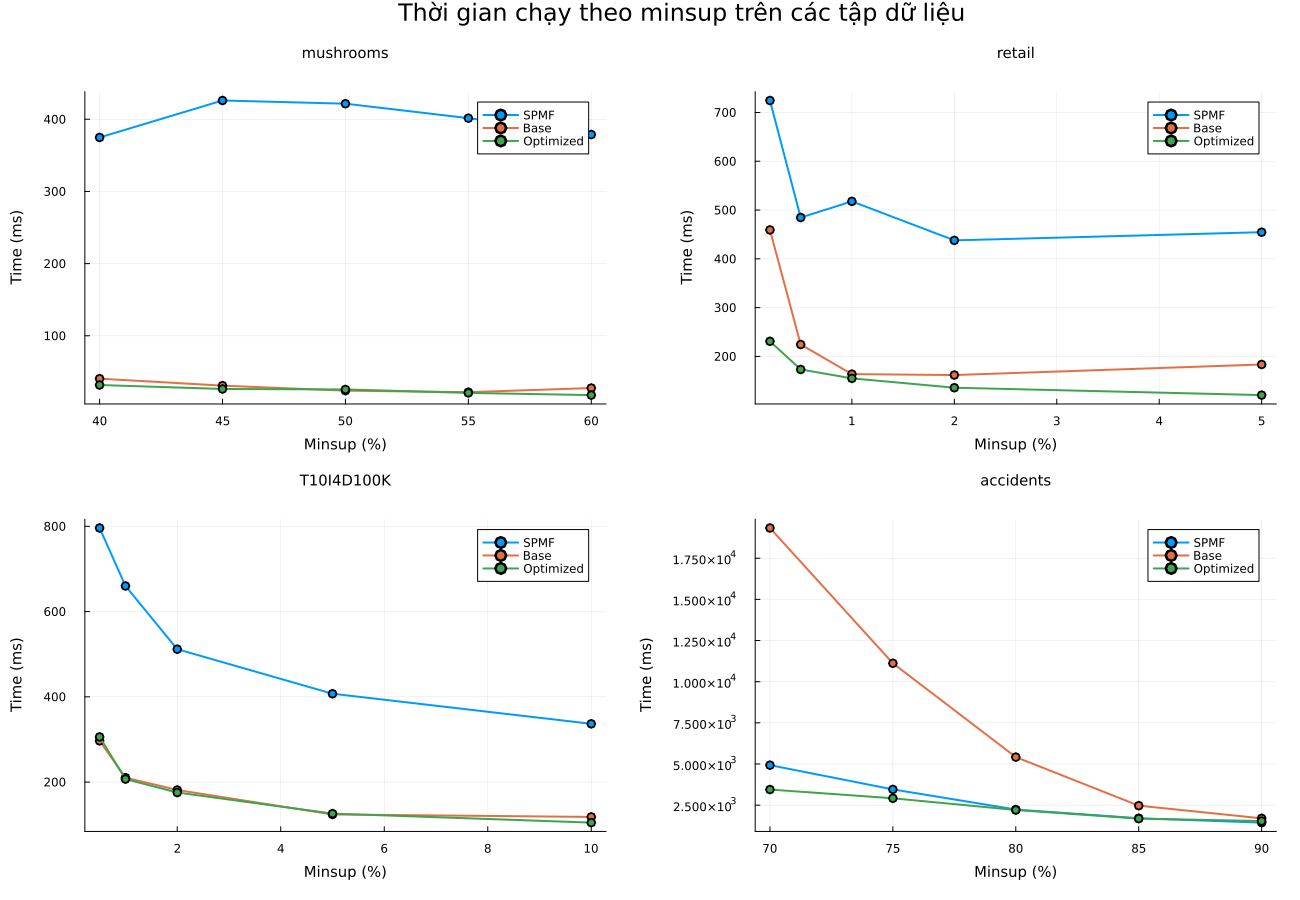

"d:\\Nam3\\KhaiThacDuLieu\\Lab2\\Lab2_HMine\\docs\\figures\\runtime_all_datasets.png"

In [18]:
plots_runtime = []

for ds in datasets
    df = filter(row -> row.Dataset == ds, benchmark_df)

    p = plot(
        title = clean_name(ds),
        xlabel = "Minsup (%)",
        ylabel = "Time (ms)",
        legend = :topright
    )

    for ver in ["SPMF", "Base", "Optimized"]
        dsub = filter(row -> row.Version == ver, df)
        sort!(dsub, :Minsup, rev=true)
        plot!(p, dsub.Minsup, dsub.Time_ms, marker=:o, linewidth=2, label=ver)
    end

    push!(plots_runtime, p)
end

runtime_figure = plot(
    plots_runtime...,
    layout = (2, 2),
    size = (1300, 900),
    plot_title = "Thời gian chạy theo minsup trên các tập dữ liệu"
)

display(runtime_figure)
savefig(runtime_figure, "../docs/figures/runtime_all_datasets.png")

## 9. Biểu đồ số lượng frequent itemset theo minsup
Biểu đồ này dùng cho mục 3.4.2(c).

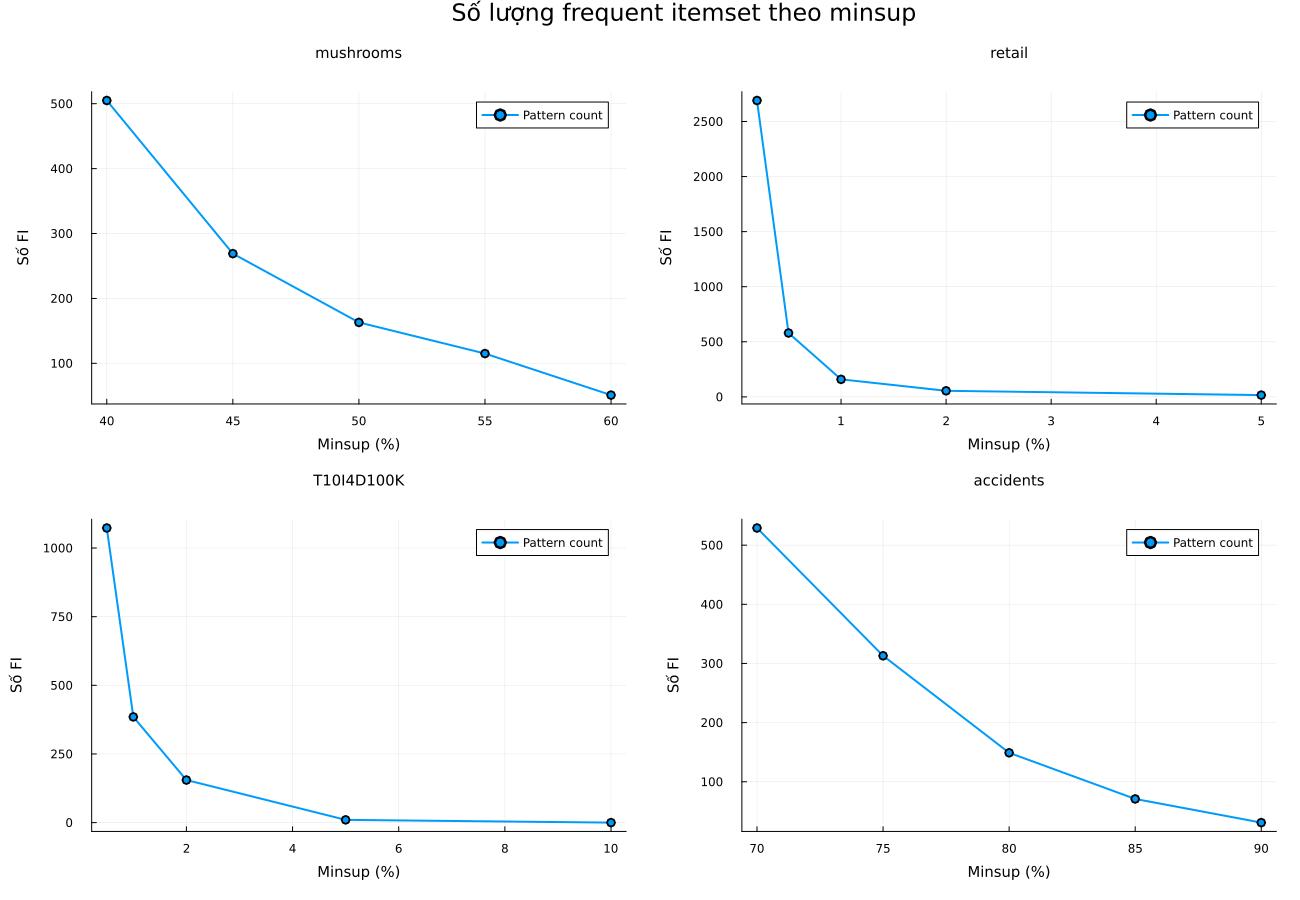

"d:\\Nam3\\KhaiThacDuLieu\\Lab2\\Lab2_HMine\\docs\\figures\\pattern_count_all_datasets.png"

In [19]:
plots_pattern = []

for ds in datasets
    df = filter(row -> row.Dataset == ds && row.Version == "Optimized", benchmark_df)
    sort!(df, :Minsup, rev=true)

    p = plot(
        df.Minsup,
        df.Pattern_Count,
        marker = :o,
        linewidth = 2,
        title = clean_name(ds),
        xlabel = "Minsup (%)",
        ylabel = "Số FI",
        label = "Pattern count",
        legend = :topright
    )

    push!(plots_pattern, p)
end

pattern_figure = plot(
    plots_pattern...,
    layout = (2, 2),
    size = (1300, 900),
    plot_title = "Số lượng frequent itemset theo minsup"
)

display(pattern_figure)
savefig(pattern_figure, "../docs/figures/pattern_count_all_datasets.png")

## 10. Biểu đồ correctness
Biểu đồ này minh họa tỉ lệ khớp so với SPMF.

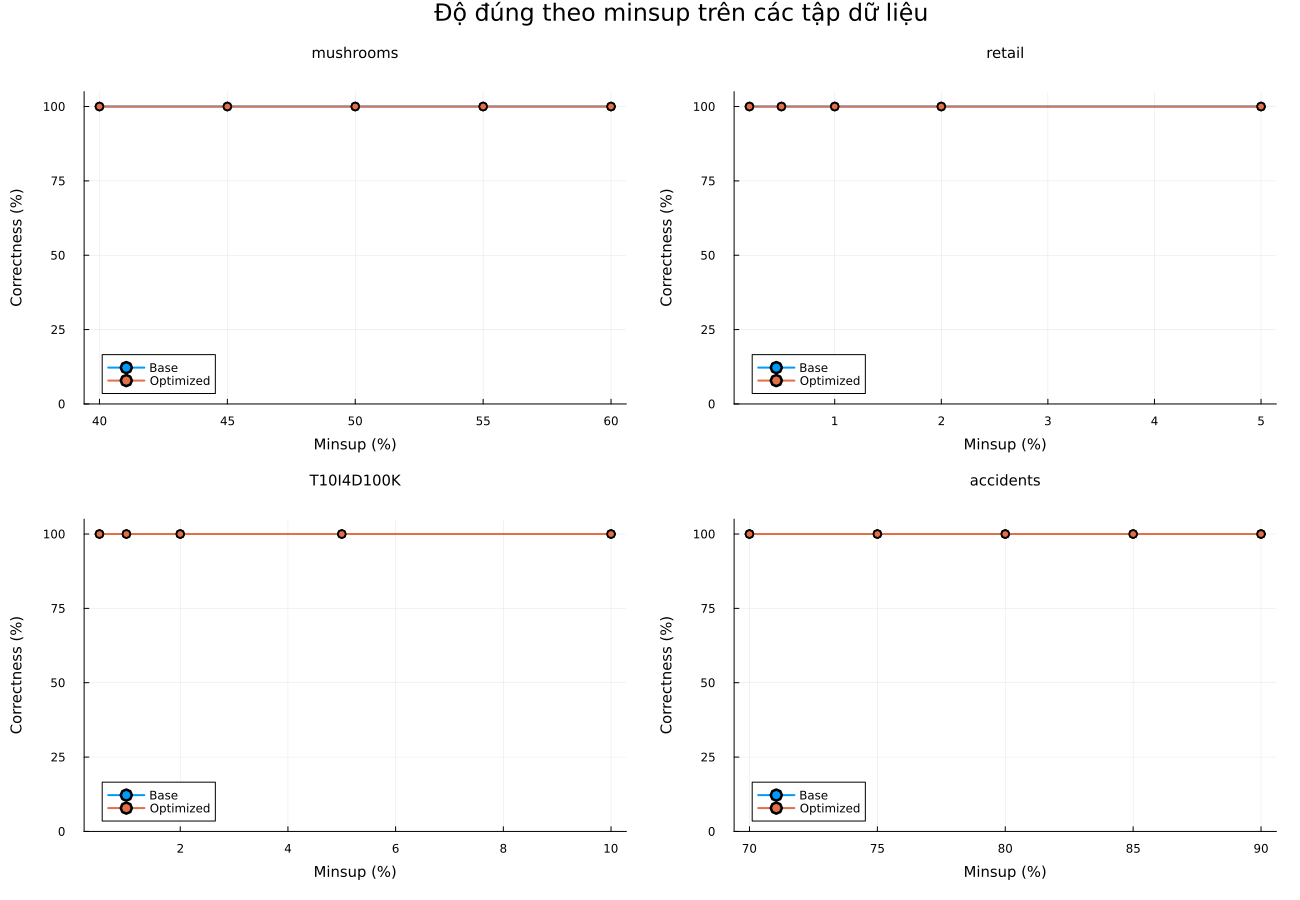

"d:\\Nam3\\KhaiThacDuLieu\\Lab2\\Lab2_HMine\\docs\\figures\\correctness_all_datasets.png"

In [20]:
plots_correctness = []

for ds in datasets
    df = filter(row -> row.Dataset == ds && row.Version != "SPMF", benchmark_df)

    p = plot(
        title = clean_name(ds),
        xlabel = "Minsup (%)",
        ylabel = "Correctness (%)",
        legend = :bottomleft,
        ylim = (0, 105)
    )

    for ver in ["Base", "Optimized"]
        dsub = filter(row -> row.Version == ver, df)
        sort!(dsub, :Minsup, rev=true)
        plot!(p, dsub.Minsup, dsub.Correctness, marker=:o, linewidth=2, label=ver)
    end

    push!(plots_correctness, p)
end

correctness_figure = plot(
    plots_correctness...,
    layout = (2, 2),
    size = (1300, 900),
    plot_title = "Độ đúng theo minsup trên các tập dữ liệu"
)

display(correctness_figure)
savefig(correctness_figure, "../docs/figures/correctness_all_datasets.png")

## 11. Biểu đồ bộ nhớ
So sánh peak memory giữa bản cơ bản và bản tối ưu.
Lưu ý: SPMF không được đo RAM bằng cùng cơ chế nên không đưa vào biểu đồ này.

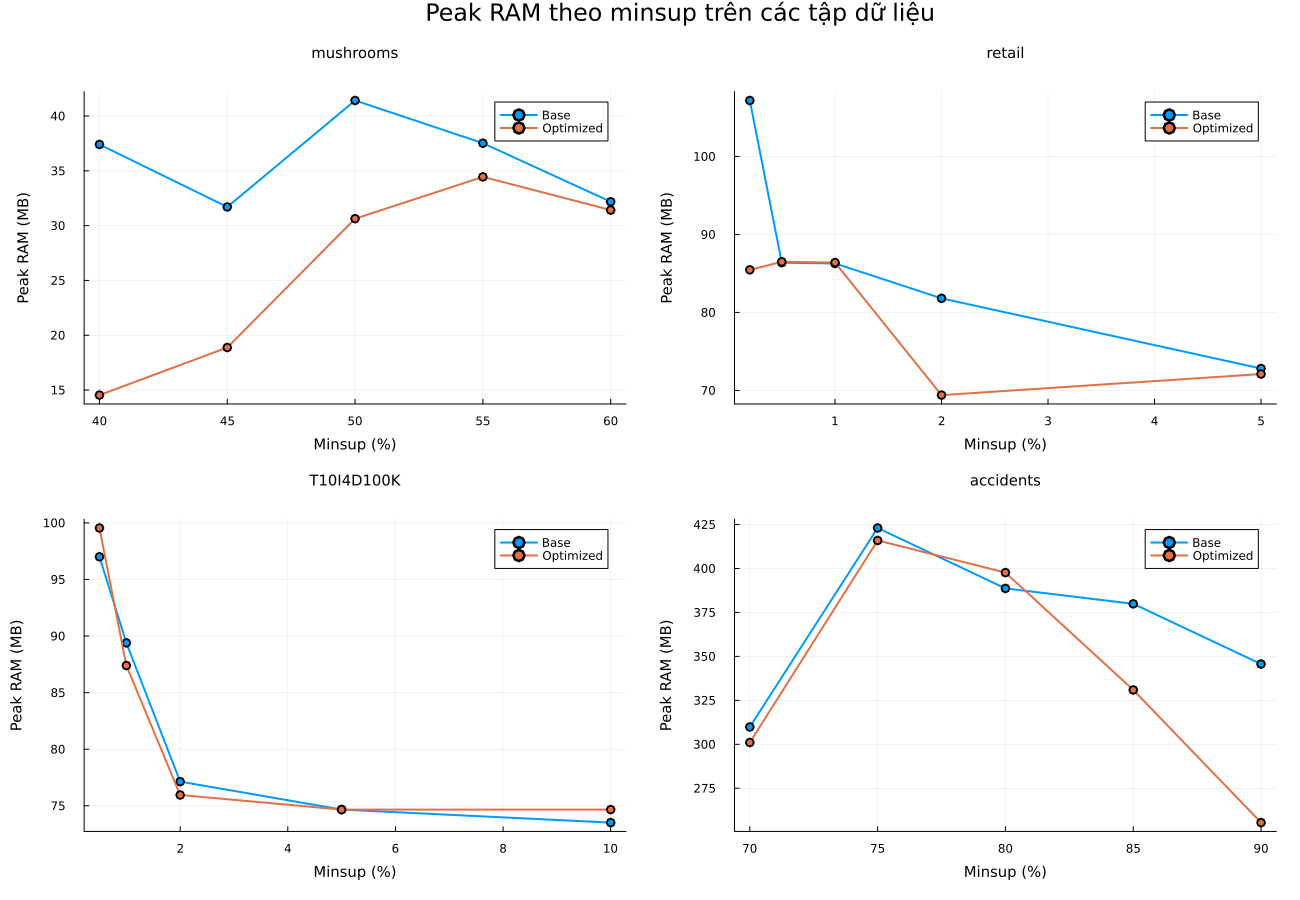

"d:\\Nam3\\KhaiThacDuLieu\\Lab2\\Lab2_HMine\\docs\\figures\\memory_all_datasets.png"

In [21]:
plots_memory = Any[]

for ds in datasets
    df = filter(row -> row.Dataset == ds && row.Version != "SPMF", benchmark_df_fixed)

    p = plot(
        title = clean_name(ds),
        xlabel = "Minsup (%)",
        ylabel = "Peak RAM (MB)",
        legend = :topright
    )

    for ver in ["Base", "Optimized"]
        dsub = filter(row -> row.Version == ver, df)
        sort!(dsub, :Minsup, rev=true)
        plot!(p, dsub.Minsup, dsub.Peak_RAM_MB, marker=:o, linewidth=2, label=ver)
    end

    push!(plots_memory, p)
end

memory_figure = plot(
    plots_memory...,
    layout = (2, 2),
    size = (1300, 900),
    plot_title = "Peak RAM theo minsup trên các tập dữ liệu"
)

display(memory_figure)
savefig(memory_figure, "../docs/figures/memory_all_datasets.png")

## 12. Biểu đồ scalability
Thể hiện thời gian chạy theo kích thước CSDL con trên tập dữ liệu lớn.

In [22]:
scalability_df

Row,Percentage,Size_lines,Time_ms,Peak_RAM_MB
,Int64,Int64,Float64,Float64
1,10,34018,175.233,50.416
2,25,85045,432.897,87.1654
3,50,170091,935.719,207.574
4,75,255137,1708.97,282.741
5,100,340183,2237.64,413.567


In [23]:
scalability_df_fixed = copy(scalability_df)
scalability_df_fixed.Peak_RAM_MB = Float64.(scalability_df_fixed.Peak_RAM_MB)

5-element Vector{Float64}:
  50.415968894958496
  87.16535568237305
 207.5740041732788
 282.7405757904053
 413.56667137145996

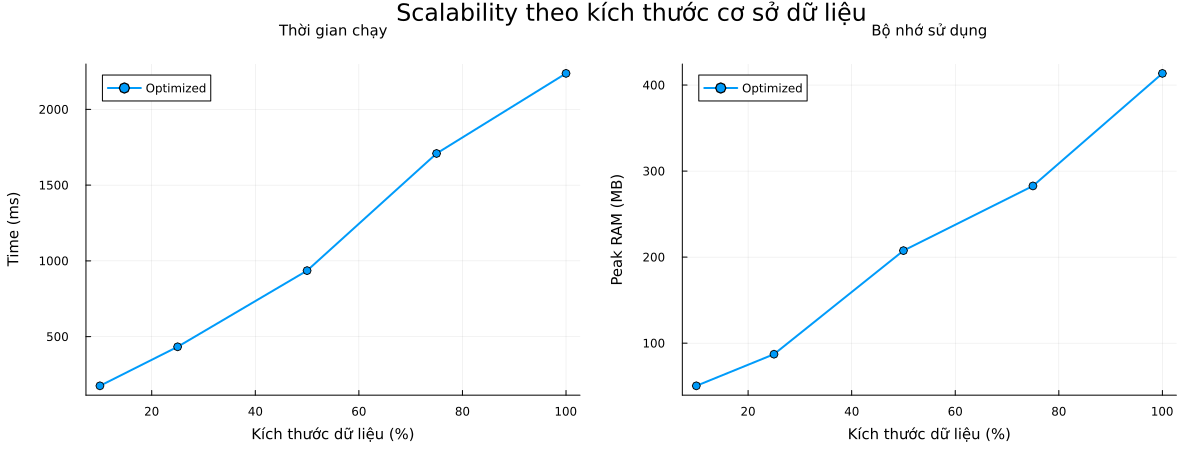

"d:\\Nam3\\KhaiThacDuLieu\\Lab2\\Lab2_HMine\\docs\\figures\\scalability_combined.png"

In [24]:
p1 = plot(
    scalability_df_fixed.Percentage,
    scalability_df_fixed.Time_ms,
    marker = :o,
    linewidth = 2,
    xlabel = "Kích thước dữ liệu (%)",
    ylabel = "Time (ms)",
    title = "Thời gian chạy",
    label = "Optimized",
    legend = :topleft
)

p2 = plot(
    scalability_df_fixed.Percentage,
    scalability_df_fixed.Peak_RAM_MB,
    marker = :o,
    linewidth = 2,
    xlabel = "Kích thước dữ liệu (%)",
    ylabel = "Peak RAM (MB)",
    title = "Bộ nhớ sử dụng",
    label = "Optimized",
    legend = :topleft
)

scalability_figure = plot(
    p1, p2,
    layout = (1, 2),
    size = (1200, 450),
    plot_title = "Scalability theo kích thước cơ sở dữ liệu"
)

display(scalability_figure)
savefig(scalability_figure, "../docs/figures/scalability_combined.png")

## 13. Ảnh hưởng của độ dài giao dịch trung bình
Biểu đồ này dùng cho mục 3.4.2(f).

In [25]:
avglen_df

Row,Avg_Transaction_Length,Time_ms,Peak_RAM_MB,Pattern_Count
,Int64,Float64,Float64,Int64
1,5,6.6412,4.88134,49
2,10,8.2234,12.8469,100
3,15,10.7443,14.6042,100
4,20,15.4391,16.525,102
5,25,475.486,66.1568,5047


In [26]:
avglen_df_fixed = copy(avglen_df)
avglen_df_fixed.Peak_RAM_MB = Float64.(avglen_df_fixed.Peak_RAM_MB)

5-element Vector{Float64}:
  4.881338119506836
 12.846881866455078
 14.60416030883789
 16.525012969970703
 66.15680408477783

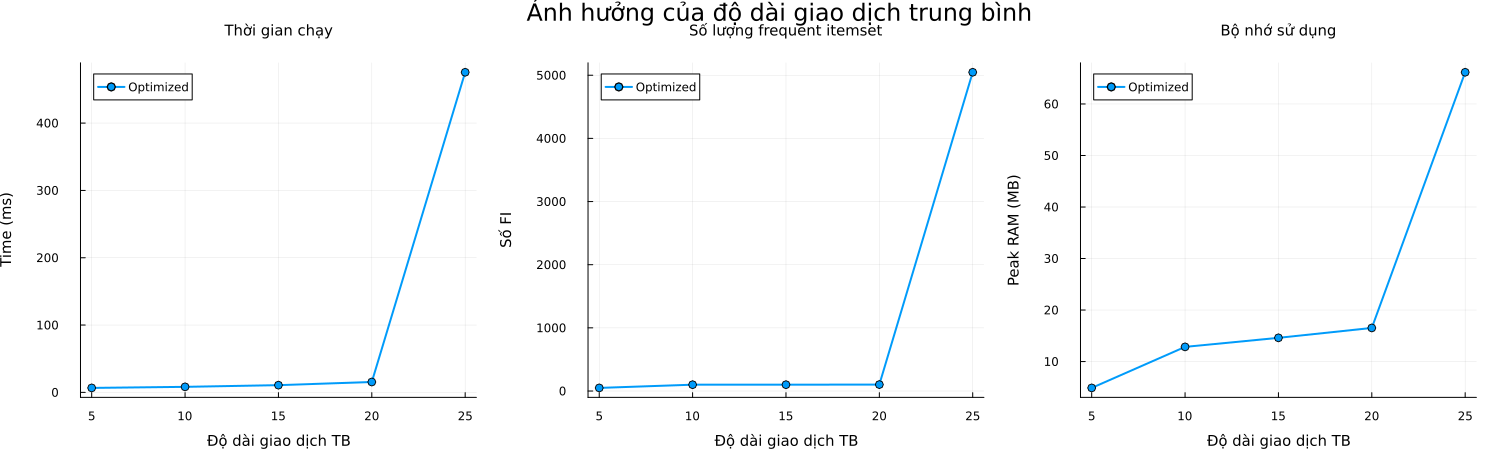

"d:\\Nam3\\KhaiThacDuLieu\\Lab2\\Lab2_HMine\\docs\\figures\\avglen_combined.png"

In [27]:
p3 = plot(
    avglen_df_fixed.Avg_Transaction_Length,
    avglen_df_fixed.Time_ms,
    marker = :o,
    linewidth = 2,
    xlabel = "Độ dài giao dịch TB",
    ylabel = "Time (ms)",
    title = "Thời gian chạy",
    label = "Optimized",
    legend = :topleft
)

p4 = plot(
    avglen_df_fixed.Avg_Transaction_Length,
    avglen_df_fixed.Pattern_Count,
    marker = :o,
    linewidth = 2,
    xlabel = "Độ dài giao dịch TB",
    ylabel = "Số FI",
    title = "Số lượng frequent itemset",
    label = "Optimized",
    legend = :topleft
)

p5 = plot(
    avglen_df_fixed.Avg_Transaction_Length,
    avglen_df_fixed.Peak_RAM_MB,
    marker = :o,
    linewidth = 2,
    xlabel = "Độ dài giao dịch TB",
    ylabel = "Peak RAM (MB)",
    title = "Bộ nhớ sử dụng",
    label = "Optimized",
    legend = :topleft
)

avglen_figure = plot(
    p3, p4, p5,
    layout = (1, 3),
    size = (1500, 450),
    plot_title = "Ảnh hưởng của độ dài giao dịch trung bình"
)

display(avglen_figure)
savefig(avglen_figure, "../docs/figures/avglen_combined.png")

## 14. Bảng tóm tắt kết quả tốt nhất của bản tối ưu


In [28]:
opt_df = filter(row -> row.Version == "Optimized", benchmark_df)
opt_df

Row,Dataset,Minsup,Version,Time_ms,Peak_RAM_MB,Correctness,Pattern_Count
,String15,Float64,String15,Float64,String31,Float64,Int64
1,mushrooms.txt,60.0,Optimized,17.8282,31.418338775634766,100.0,51
2,mushrooms.txt,55.0,Optimized,20.8853,34.44710159301758,100.0,115
3,mushrooms.txt,50.0,Optimized,25.648,30.633045196533203,100.0,163
4,mushrooms.txt,45.0,Optimized,26.3117,18.879329681396484,100.0,269
5,mushrooms.txt,40.0,Optimized,31.7933,14.537090301513672,100.0,505
6,retail.txt,5.0,Optimized,120.691,72.10448741912842,100.0,16
7,retail.txt,2.0,Optimized,135.813,69.40225601196289,100.0,55
8,retail.txt,1.0,Optimized,154.986,86.39650344848633,100.0,159
9,retail.txt,0.5,Optimized,173.24,86.4973201751709,100.0,580


In [29]:
combine(groupby(opt_df, :Dataset)) do sdf
    DataFrame(
        Best_Time_ms = minimum(sdf.Time_ms),
        Max_Correctness = maximum(sdf.Correctness),
        Min_Peak_RAM_MB = minimum(skipmissing(sdf.Peak_RAM_MB)),
        Max_Pattern_Count = maximum(sdf.Pattern_Count)
    )
end

Row,Dataset,Best_Time_ms,Max_Correctness,Min_Peak_RAM_MB,Max_Pattern_Count
,String15,Float64,Float64,String31,Int64
1,mushrooms.txt,17.8282,100.0,14.537090301513672,505
2,retail.txt,120.691,100.0,69.40225601196289,2691
3,T10I4D100K.txt,104.905,100.0,74.6619005203247,1073
4,accidents.txt,1533.3,100.0,255.4700107574463,529


## 15. Kết luận

Từ các bảng số liệu và biểu đồ trong notebook, có thể rút ra một số nhận xét chính như sau:

- **Về tính đúng đắn:** cài đặt của nhóm cho kết quả khớp với SPMF trên các tập dữ liệu đã kiểm thử. Điều này cho thấy thuật toán đã được hiện thực đúng và ổn định.
- **Về thời gian chạy:** khi `minsup` giảm, thời gian chạy của các phiên bản đều có xu hướng tăng, do số lượng frequent itemset và số nhánh cần khai phá tăng lên.
- **Về số lượng frequent itemset:** số lượng mẫu phổ biến tăng rõ rệt khi `minsup` giảm. Ở các mức `minsup` giống nhau, các phiên bản cho số lượng frequent itemset trùng nhau, nên các đường trên biểu đồ gần như chồng khít.
- **Về bộ nhớ:** bản tối ưu nhìn chung có xu hướng sử dụng bộ nhớ hiệu quả hơn hoặc tương đương bản cơ bản trên nhiều cấu hình, dù mức cải thiện không hoàn toàn đồng đều trên mọi tập dữ liệu.
- **Về khả năng mở rộng:** khi kích thước cơ sở dữ liệu tăng từ 10\% lên 100\%, thời gian chạy và bộ nhớ đều tăng theo. Xu hướng này cho thấy cài đặt của nhóm có khả năng mở rộng tương đối tốt trên dữ liệu lớn.
- **Về ảnh hưởng của độ dài giao dịch trung bình:** khi độ dài giao dịch tăng, thời gian chạy, bộ nhớ và số lượng frequent itemset cũng có xu hướng tăng. Điều này phù hợp với lý thuyết, vì giao dịch dài hơn làm tăng khả năng đồng xuất hiện của các item và mở rộng không gian tìm kiếm.
